In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans , AgglomerativeClustering , DBSCAN
from kneed import KneeLocator
from sklearn.metrics import silhouette_score



In [ ]:
df = pd.read_csv("smartcart_customers.csv")
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [ ]:
df.duplicated().sum()

0

## 1) Data preprocessing

In [ ]:
# Handle missing values

In [ ]:
df["Income"]= df["Income"].fillna(df["Income"].median())

In [ ]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## 2) Feature Engineering 

In [ ]:
# Age

In [ ]:
df["Age"] = 2026-df["Year_Birth"]

In [ ]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
1607,4656,1990,2n Cycle,Single,51250.0,1,0,30-03-2013,28,342,...,32,40,5,10,5,4,9,0,0,36


In [ ]:
# Customer joining date

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] =( reference_date - df["Dt_Customer"]).dt.days

In [ ]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
1534,3745,1988,2n Cycle,Married,23331.0,1,0,2012-09-04,92,5,...,45,2,3,0,3,8,0,0,38,663


In [ ]:
# Spending

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [ ]:
df["Total_spending"]= df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"]

In [ ]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending
1402,2534,1953,Graduation,Married,37716.0,0,1,2014-04-21,4,97,...,2,4,1,3,7,0,0,73,69,188


In [ ]:
# childrens 

In [ ]:
df["Total_childrens"] = df["Kidhome"] + df["Teenhome"]

In [ ]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_childrens
438,5455,1971,PhD,Married,32011.0,1,0,2013-08-22,89,99,...,2,1,4,7,0,0,55,311,122,1


In [ ]:
# Education

In [ ]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [ ]:
# Conver all this in tree catogres 

In [ ]:
df["Education"] = df["Education"].replace(
    {
        "Graduation" : "Graduate",
        "2n Cycle" : "Undergraduate" , "Basic" : "Undergraduate",
        "PhD" : "Postgraduate" , "Master" : "Postgraduate"
        
    }
)

In [ ]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [ ]:
# Marital Status

In [ ]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [ ]:
df["Living_Together"] = df["Marital_Status"].replace(
    {
        "Together" : "Patner", "Married":"Patner",
        "YOLO" : "Alone" , "Absurd" : "Alone",
        "Widow" : "Alone" , "Divorced" : "Alone" , "Single": "Alone"
        
    }
)

In [ ]:
df["Living_Together"].value_counts()

Living_Together
Patner    1444
Alone      796
Name: count, dtype: int64

### Drop Columns

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_spending',
       'Total_childrens', 'Living_Together'],
      dtype='object')

In [ ]:
cols = ["Year_Birth", "ID","Dt_Customer", "Teenhome","Kidhome","Marital_Status" , "MntMeatProducts","MntFruits","MntWines","MntSweetProducts","MntFishProducts","MntGoldProds"]

In [ ]:
df_cleaned = df.drop(columns= cols)

In [ ]:
df_cleaned.shape

(2240, 15)

In [ ]:
df_cleaned.sample()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_childrens,Living_Together
2138,Postgraduate,62637.0,76,1,2,2,5,2,0,0,72,120,185,1,Alone


## Outliers 

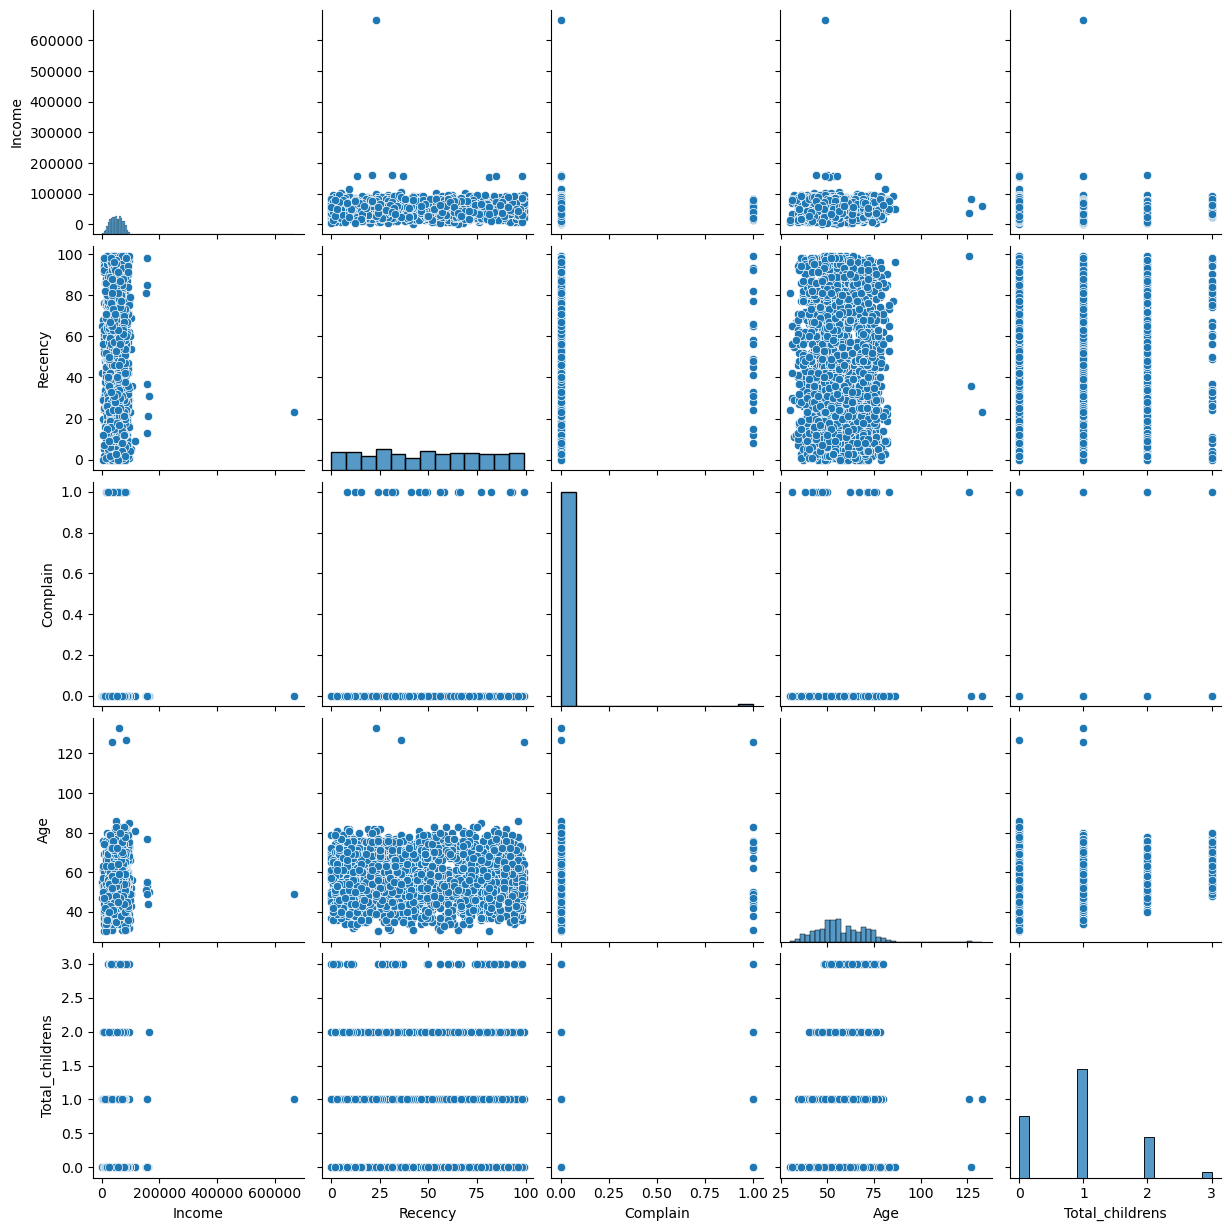

In [ ]:
cols = ["Income","Recency","Complain","Age", "Living_Together","Total_childrens"]

sns.pairplot(df_cleaned[cols])

> 1) So here the first outlier is in income with 600000 

> 2) IN Age there is an wrong value of an 120+ age

In [ ]:
print("Before removing outlier :", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"]< 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]< 600_000) ]

print("After removing outlier :", len(df_cleaned))

Before removing outlier : 2240
After removing outlier : 2236


* Total 4 outliers are removed 

## Heatmap

In [ ]:
data = df_cleaned.corr(numeric_only = True)


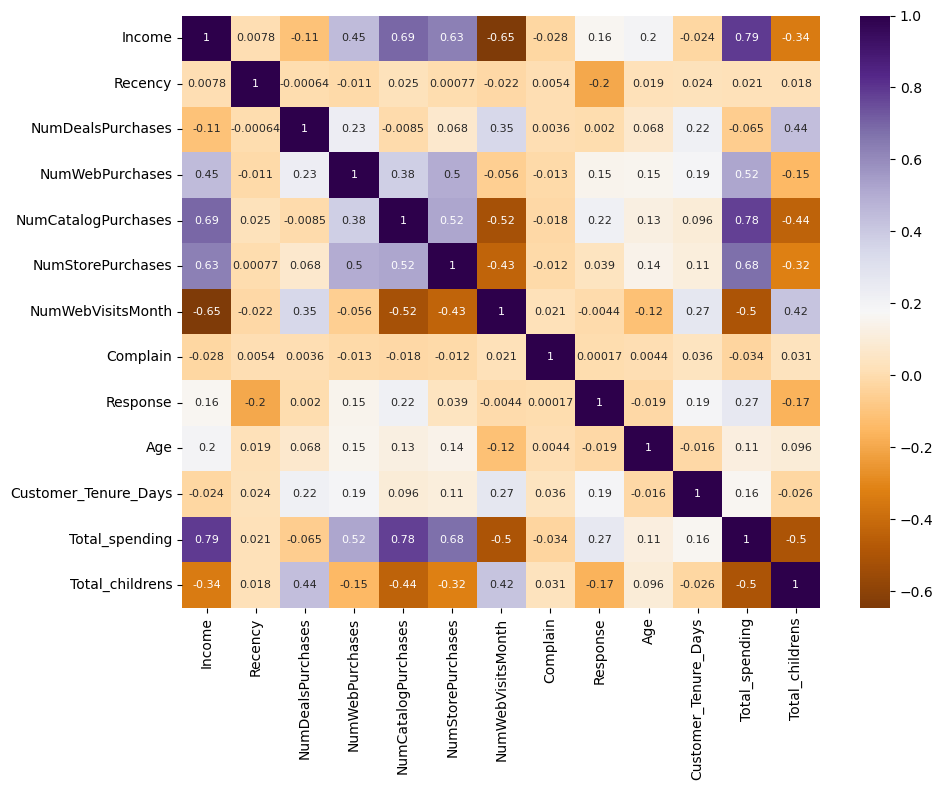

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(data , cmap="PuOr" , annot= True , annot_kws={"size":8})

plt.tight_layout()

> So here first coreation is income and total spendings is 0.79 highest , it means if income increses total spending also increses 

> 2) categalog purchase and income is 0.69

> 3) store purchase is 0.63

> 4) also the high income purchaser are not visting website , -0.65

> 5) max total spending is from catelog 0.78

## Encoding 

In [ ]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_Together"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
enc_df =pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [ ]:
df_encode = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [ ]:
df_encode.shape

(2236, 18)

## Scaling

In [ ]:
x = df_encode

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

## Visualization

In [ ]:
x_scaled.shape

(2236, 18)

* so here are 18 features so we cant visualize 18 features for that we gona use pca

In [ ]:
# 2d visualization

In [ ]:
pca = PCA(n_components= 3)
x_pca = pca.fit_transform(x_scaled)



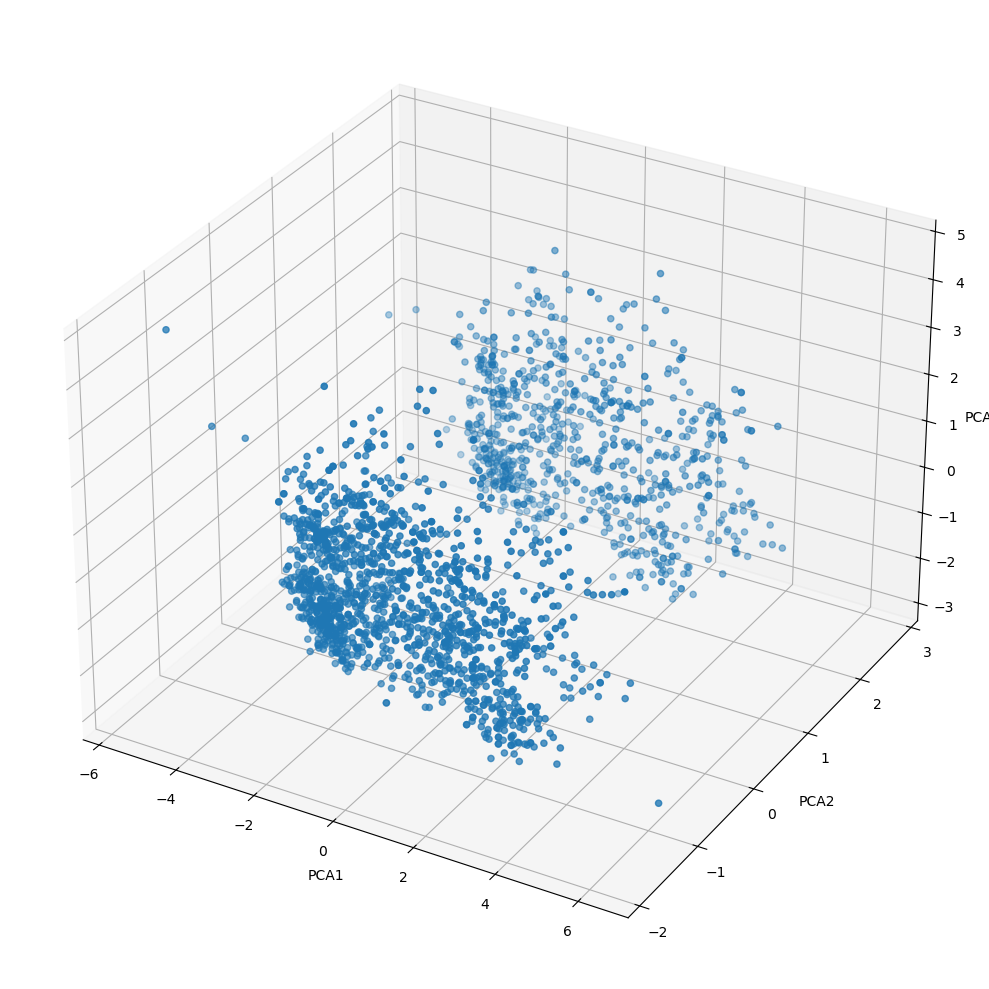

In [ ]:
fig = plt.figure(figsize=(10,10))
ax= fig.add_subplot(111, projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.tight_layout()

In [ ]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

> so we capuring 0.231.. +0.113.. = 34% in 2d

> for 3d it is 44% 

## finding the value of k 

### 1) Elbow method

In [ ]:
wcss =[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state= 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [ ]:
knee = KneeLocator(range(1,11),wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("the value of optimal k :",optimal_k)

the value of optimal k : 4


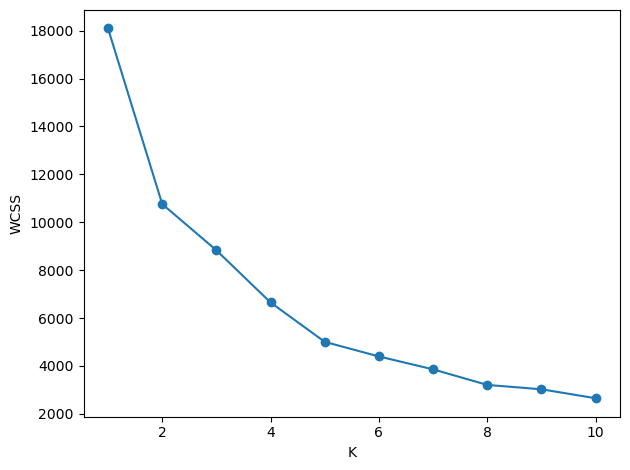

In [ ]:
# plot
plt.plot(range(1,11), wcss, marker ="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.tight_layout()

### 2) silhouette score

In [ ]:
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters= k , random_state=42)
    labels = kmeans.fit_predict(x_pca)
    sc = silhouette_score(x_pca, labels)
    scores.append(sc)

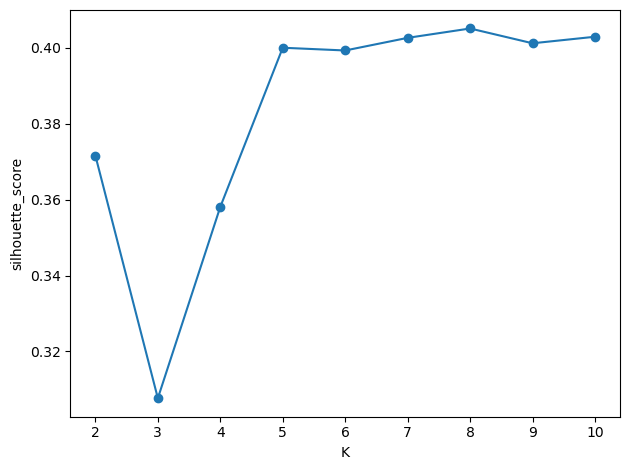

In [ ]:
# plot
plt.plot(range(2,11), scores, marker ="o")
plt.xlabel("K")
plt.ylabel("silhouette_score")
plt.tight_layout()

Text(0, 0.5, 'SS')

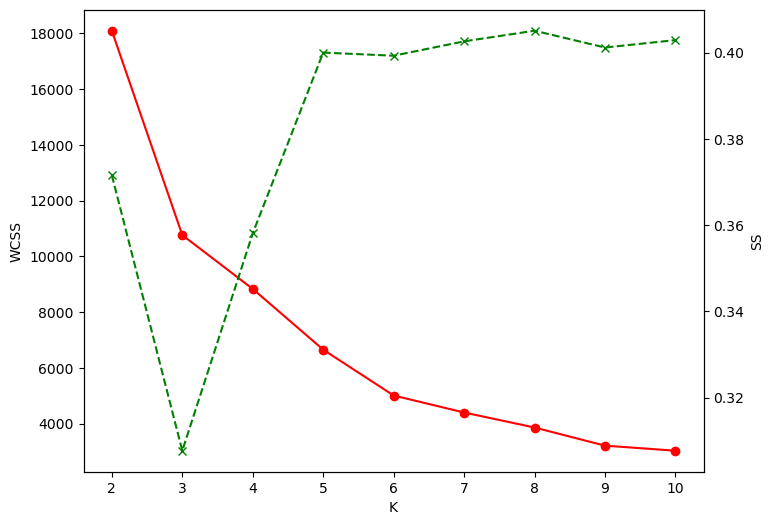

In [ ]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="red") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="green", linestyle="--")
ax2.set_ylabel("SS")

* Here both are intersecting at the point 4 so our optimal K value is 4 

# Clustring

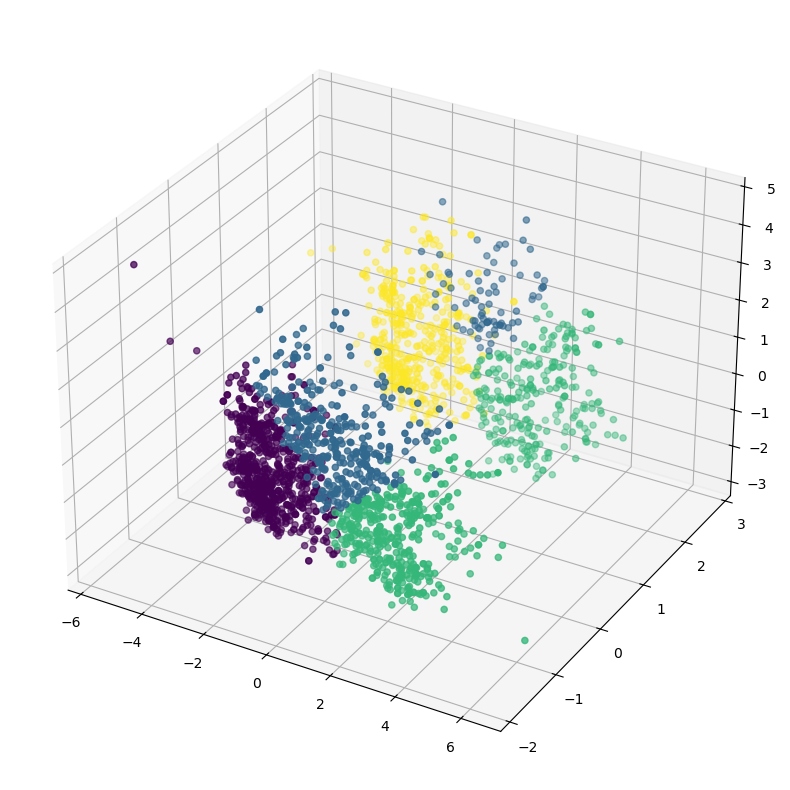

In [ ]:
#kmeans 

kmeans = KMeans(n_clusters= 4 , random_state=42)
k_labels = kmeans.fit_predict(x_pca)

                              
fig = plt.figure(figsize=(10,10))
ax= fig.add_subplot(111, projection ="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c= k_labels)

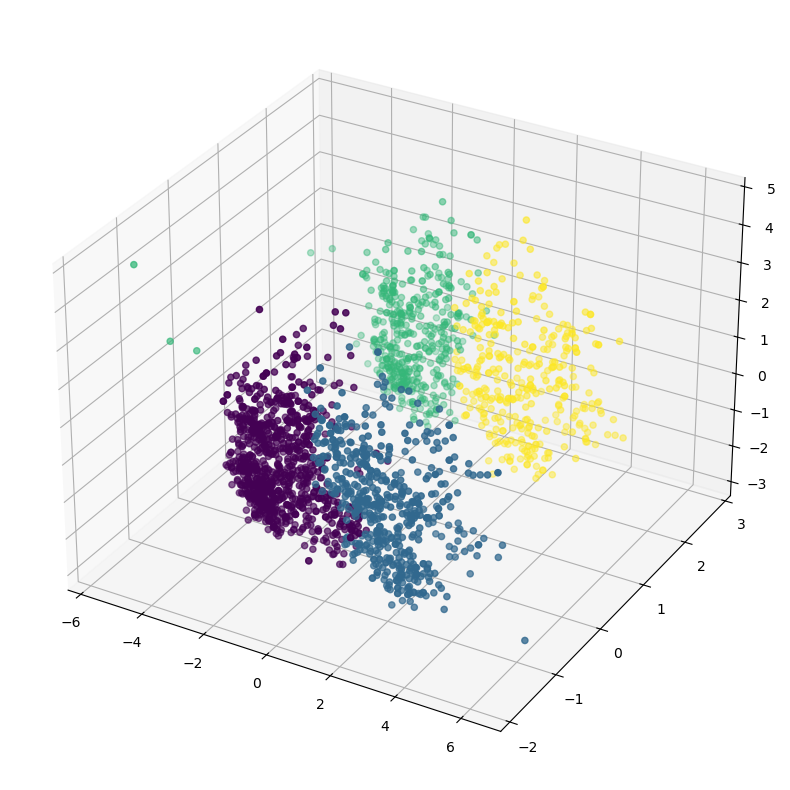

In [ ]:
# Agglomerative Clustering
agc = AgglomerativeClustering(n_clusters=4)
agc_labels = agc.fit_predict(x_pca)


fig = plt.figure(figsize=(10,10))
ax= fig.add_subplot(111, projection ="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c= agc_labels)

* IT shows better clustering so we gona use it 

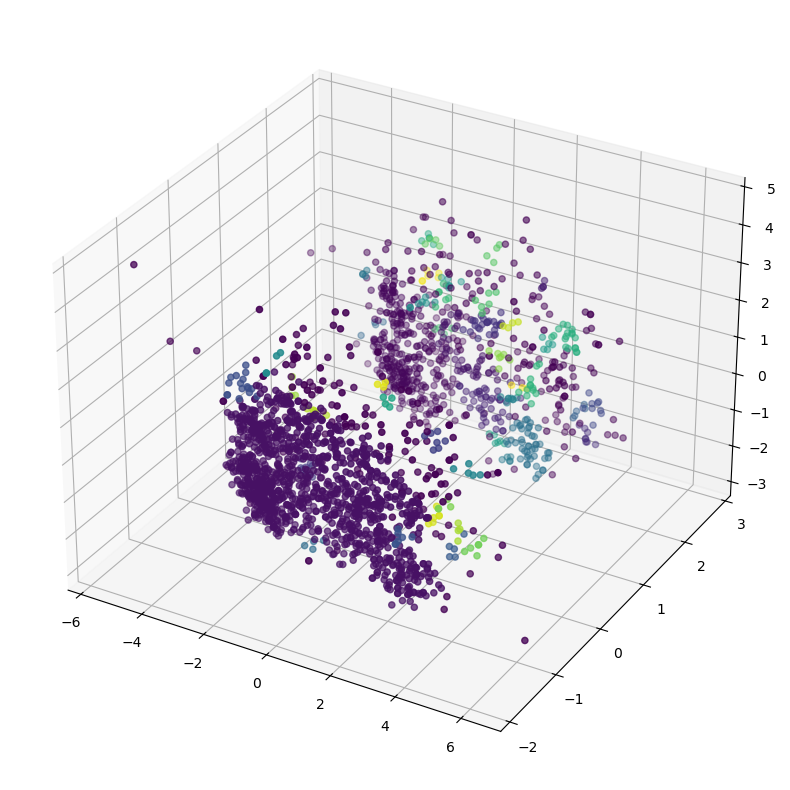

In [ ]:
# DBscan 
db = DBSCAN(eps=0.3, min_samples= 4)
db_labels = db.fit_predict(x_pca)

fig = plt.figure(figsize=(10,10))
ax= fig.add_subplot(111, projection ="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c= db_labels)


In [ ]:
import numpy as np

labels = db_labels
unique_labels = set(labels)

n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters: 46
Number of noise points: 337


> It gaves almost 46 cluster that is not good 

# Analysing the clusters 

In [ ]:
x["cluster"] = agc_labels

In [ ]:
df_cleaned.sample(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_childrens,Living_Together
378,Postgraduate,66426.0,14,2,3,5,10,6,0,0,65,270,1377,1,Patner
1337,Postgraduate,35876.0,13,1,3,1,3,6,0,0,43,70,129,0,Patner
2067,Postgraduate,77610.0,70,2,4,7,4,7,0,0,74,608,1680,1,Patner
818,Graduate,65685.0,54,1,9,2,9,5,0,0,54,92,769,1,Patner
2184,Undergraduate,53233.0,18,1,1,0,3,4,0,0,69,103,40,1,Patner


<Axes: xlabel='cluster', ylabel='count'>

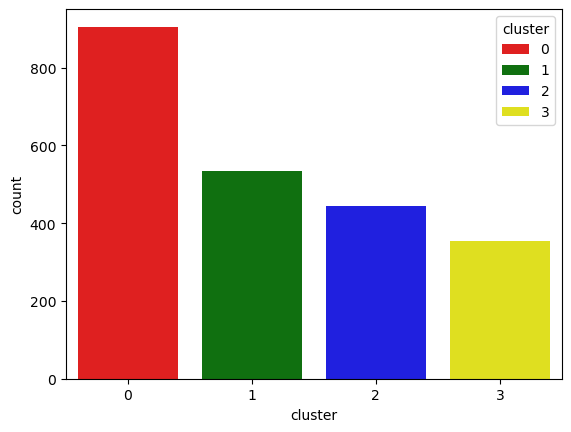

In [ ]:
color = ["red", "green","blue", "yellow"]

sns.countplot(x = x["cluster"], palette=color, hue= x["cluster"])

In [ ]:
# 1) total spending and income rtio

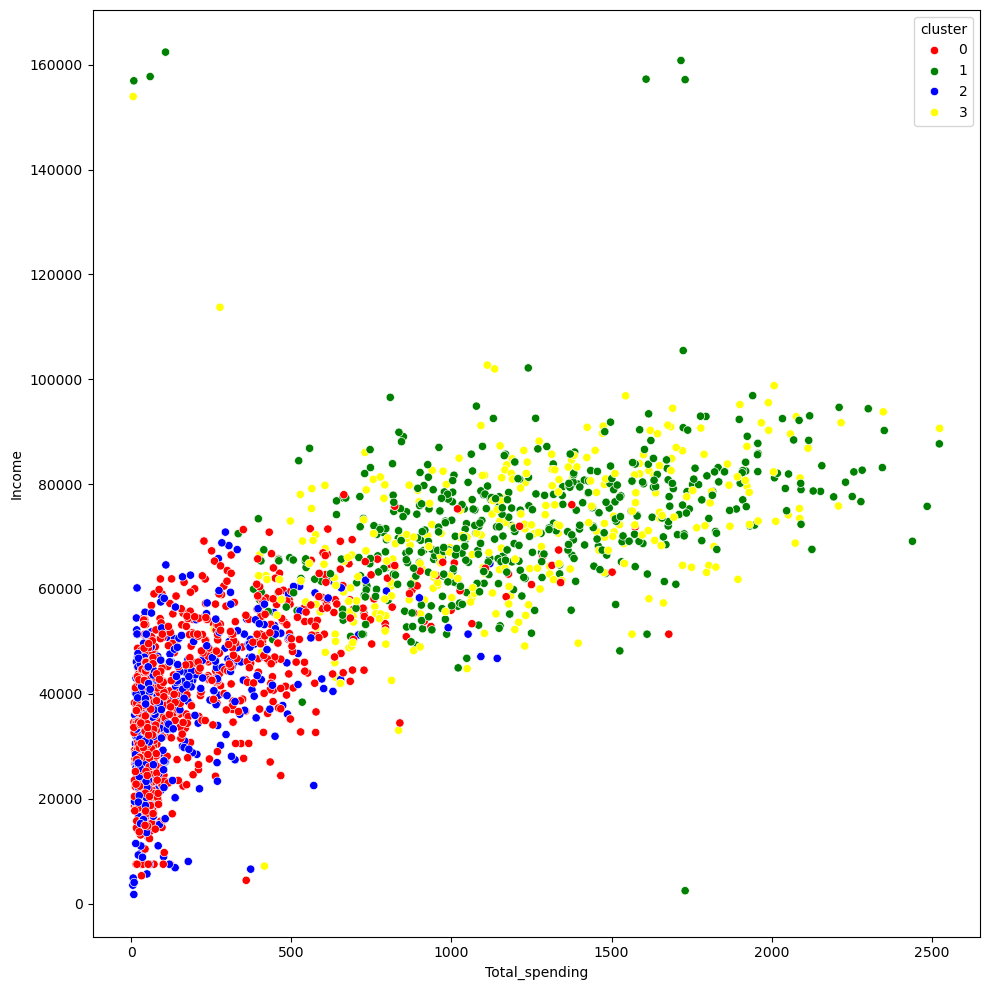

In [ ]:
plt.figure(figsize=(10,10))
sns.scatterplot(x=x["Total_spending"], y = x["Income"], hue=x["cluster"], palette=color )
plt.tight_layout()

> 1) Cluster red(0) : Here total spending is mix of low/moderate while the income is low/ moderate below 8000

> 2) Cluster green(1) : it has highest income upto 16_000 , while total spending is also medium to high   

> 3) cluster blue(2) : it is low income and low spending 

> 4) cluster yellow(3): it has high spending but moderate income

* cluster 1 and 3 has high spending and income 

# Cluster summary

In [ ]:
cluster_summary = x.groupby("cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Together_Alone,Living_Together_Patner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


# SmartCart — E-commerce Customer Segmentation Summary

## Cluster Profiles

### Cluster 0 — "Family Shoppers" 🏷️ (Discounts & Coupons)
- More children
- Poor campaign response
- Have partners
- Web visits high
- Web, catalog, store purchases low

### Cluster 1 — "Loyalty Program Candidates" 💸 (Price Sensitive)
- Fewer children
- Slightly higher age
- Average response
- Have partners
- Web visits are low
- Store & catalog high, Web visits low

### Cluster 2 — "Digital Browsers" 🛍️ (Sales & Heavy Discount Comfort)
- More children
- Average response
- Single/alone
- Web visits high
- Web, catalog, store very high

### Cluster 3 — "High Value Singles" ⭐ (Best ROI / Premium Services)
- Fewer children
- Slightly higher age
- Best campaign response
- Single/alone
- Web visits low
- Store & catalog , Web high 

---

## Income / Spending Mapping (by color)

| Cluster | Color  | Income            | Spending           | Segment Type        |
|---------|--------|-------------------|--------------------|----------------------|
| 0       | Red    | Low / Moderate    | Low / Moderate     | Price Sensitive      |
| 1       | Blue   | High              | High               | Premium Customer     |
| 2       | Yellow | Low               | Low                | Budget Segment       |
| 3       | Green  | Moderate–High     | High               | Premium Customer     |

---

## Key Strategic Takeaways
- **Clusters 1 & 3 (Blue & Green)** → High spenders → target with **premium services / loyalty programs**
- **Cluster 0 (Red)** → Price-sensitive families → target with **discounts & coupons**
- **Cluster 2 (Yellow)** → Low income, digital-first → target with **sales promotions & discount offers**